In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

plt.style.use('ggplot')

In [ ]:
crop_production_df = pd.read_csv('/content/crop_production.csv')
crop_recommendation_df = pd.read_csv('/content/Crop_recommendation.csv')

In [ ]:
column_mapping = {
    'State_Name': 'State',
    'state_name': 'State',
    'District_Name': 'District',
    'district_name': 'District',
    'Crop_Year': 'Year',
    'crop_year': 'Year'
}

crop_production_df.rename(columns=column_mapping, inplace=True)

expected_cols = ['State', 'District', 'Crop', 'Season', 'Area', 'Production', 'Year']

for col in expected_cols:
    if col not in crop_production_df.columns:
        crop_production_df[col] = np.nan

crop_production_df = crop_production_df[expected_cols]

In [ ]:
crop_production_df.dropna(subset=['Crop', 'Area', 'Production'], inplace=True)

crop_production_df = crop_production_df[crop_production_df['Area'] > 0]
crop_production_df = crop_production_df[crop_production_df['Production'] > 0]

In [ ]:
crop_production_df['Yield'] = crop_production_df['Production'] / crop_production_df['Area']

In [ ]:
q25 = crop_production_df['Yield'].quantile(0.25)
q50 = crop_production_df['Yield'].quantile(0.50)

def assign_risk_level(yield_value):
    if yield_value <= q25:
        return 2
    elif yield_value <= q50:
        return 1
    else:
        return 0

crop_production_df['risk_level'] = crop_production_df['Yield'].apply(assign_risk_level).astype(int)

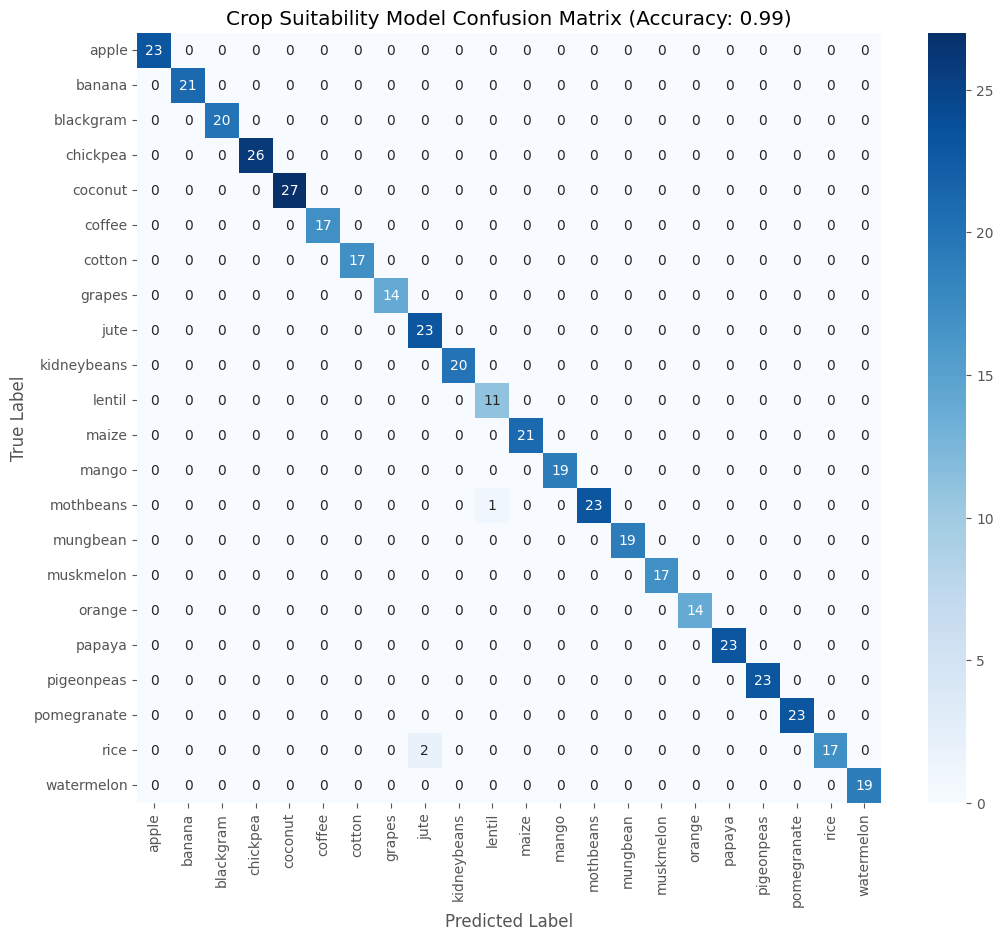

In [ ]:
X_rec = crop_recommendation_df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y_rec = crop_recommendation_df['label']

X_train_rec, X_test_rec, y_train_rec, y_test_rec = train_test_split(X_rec, y_rec, test_size=0.2, random_state=42)

rf_classifier_rec = RandomForestClassifier(random_state=42)
rf_classifier_rec.fit(X_train_rec, y_train_rec)

y_pred_rec = rf_classifier_rec.predict(X_test_rec)
accuracy_rec = accuracy_score(y_test_rec, y_pred_rec)

cm_rec = confusion_matrix(y_test_rec, y_pred_rec)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_rec, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_classifier_rec.classes_, yticklabels=rf_classifier_rec.classes_)
plt.title(f'Crop Suitability Model Confusion Matrix (Accuracy: {accuracy_rec:.2f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

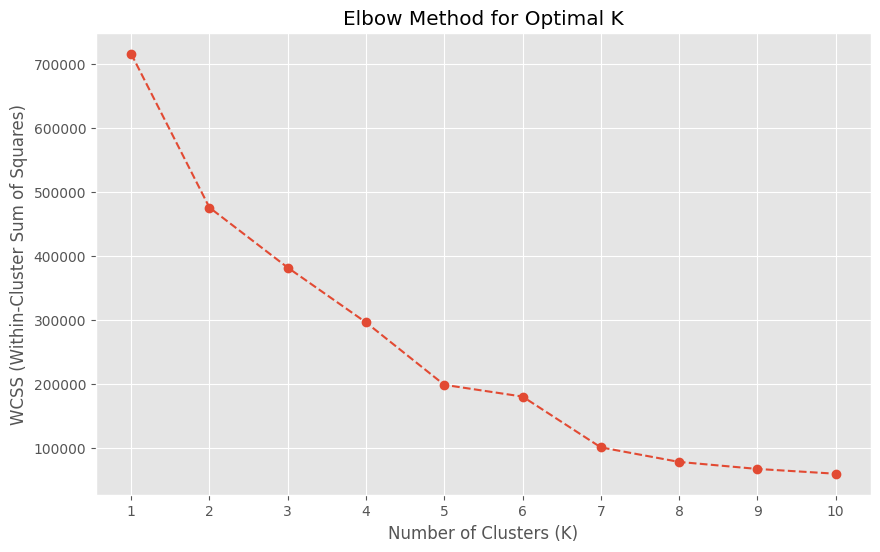

In [ ]:
clustering_features = crop_production_df[['Area', 'Production', 'Yield']].copy()
scaler_clustering = StandardScaler()
clustering_features_scaled = scaler_clustering.fit_transform(clustering_features)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(clustering_features_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init='auto')
crop_production_df['Cluster'] = kmeans_final.fit_predict(clustering_features_scaled)

/tmp/ipykernel_907/2784328232.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='State', y='Production', data=df_top_states.groupby('State')['Production'].sum().reset_index(), palette='viridis')


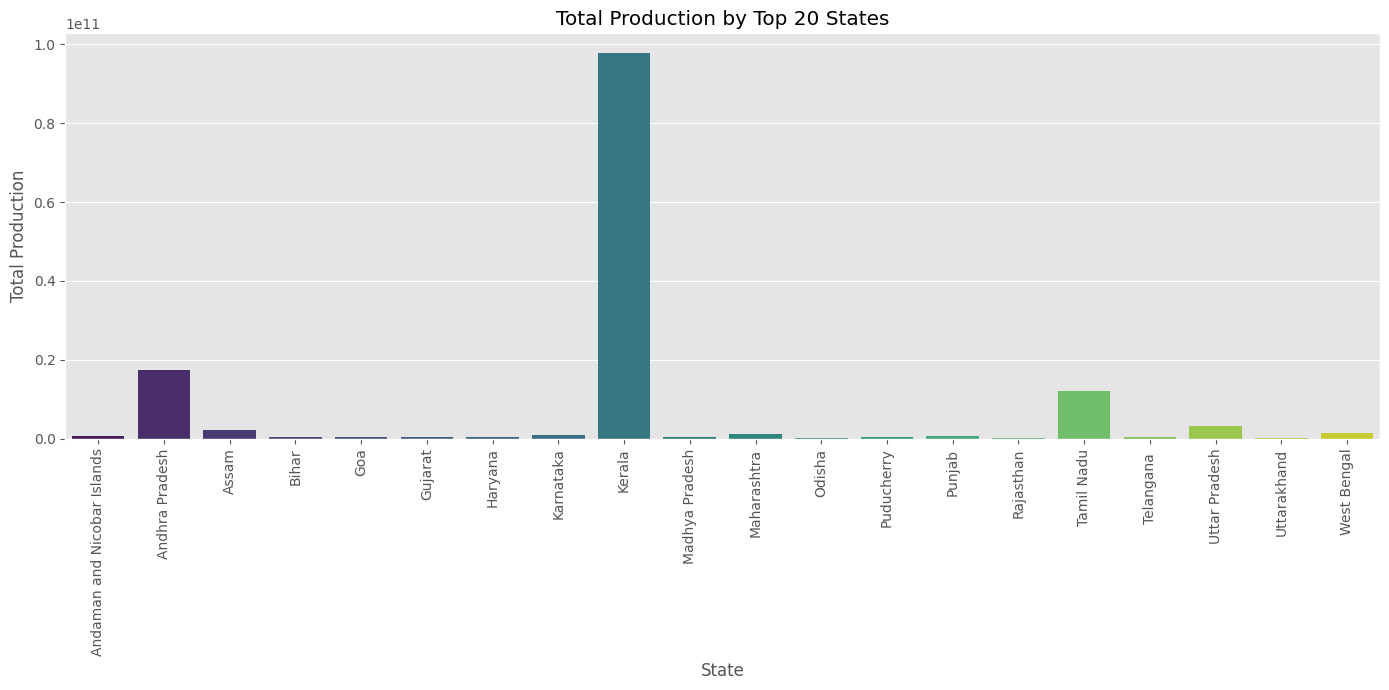

In [ ]:
top_20_states = crop_production_df.groupby('State')['Production'].sum().nlargest(20).index
df_top_states = crop_production_df[crop_production_df['State'].isin(top_20_states)]

plt.figure(figsize=(14, 7))
sns.barplot(x='State', y='Production', data=df_top_states.groupby('State')['Production'].sum().reset_index(), palette='viridis')
plt.title('Total Production by Top 20 States')
plt.xlabel('State')
plt.ylabel('Total Production')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

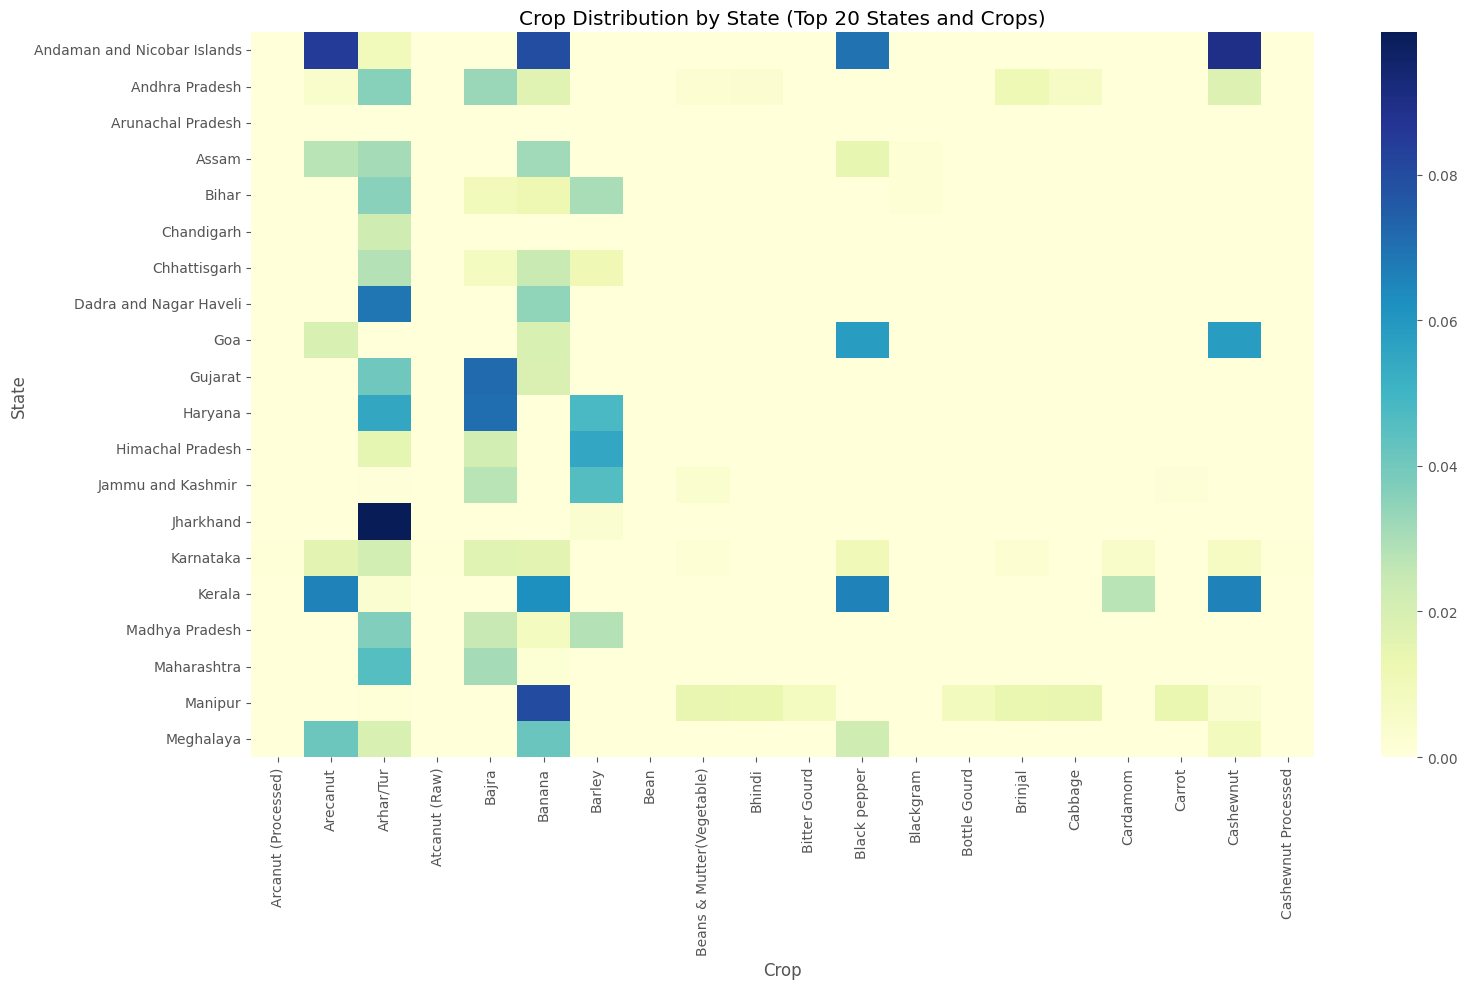

In [ ]:
plt.figure(figsize=(16, 10))
crop_state_pivot = crop_production_df.groupby(['State', 'Crop']).size().unstack(fill_value=0)
sns.heatmap(crop_state_pivot.apply(lambda x: x / x.sum(), axis=1).iloc[:20, :20], cmap='YlGnBu')
plt.title('Crop Distribution by State (Top 20 States and Crops)')
plt.xlabel('Crop')
plt.ylabel('State')
plt.tight_layout()
plt.show()

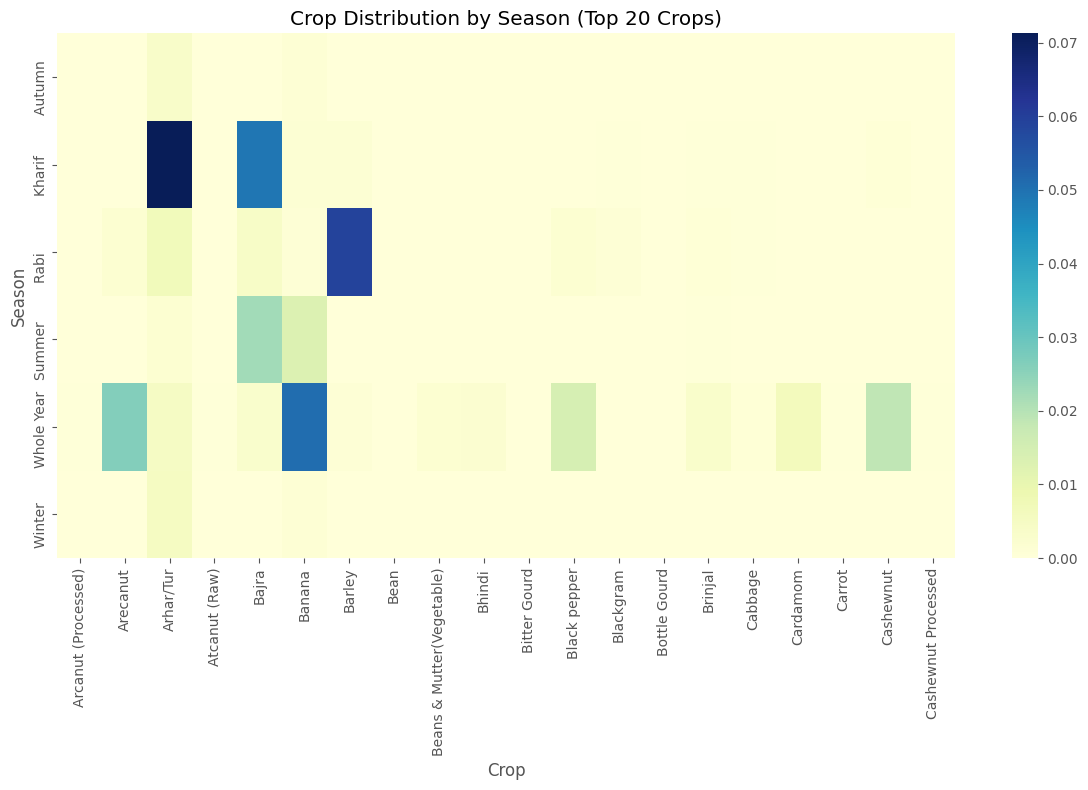

In [ ]:
plt.figure(figsize=(12, 8))
crop_season_pivot = crop_production_df.groupby(['Season', 'Crop']).size().unstack(fill_value=0)
sns.heatmap(crop_season_pivot.apply(lambda x: x / x.sum(), axis=1).iloc[:, :20], cmap='YlGnBu')
plt.title('Crop Distribution by Season (Top 20 Crops)')
plt.xlabel('Crop')
plt.ylabel('Season')
plt.tight_layout()
plt.show()

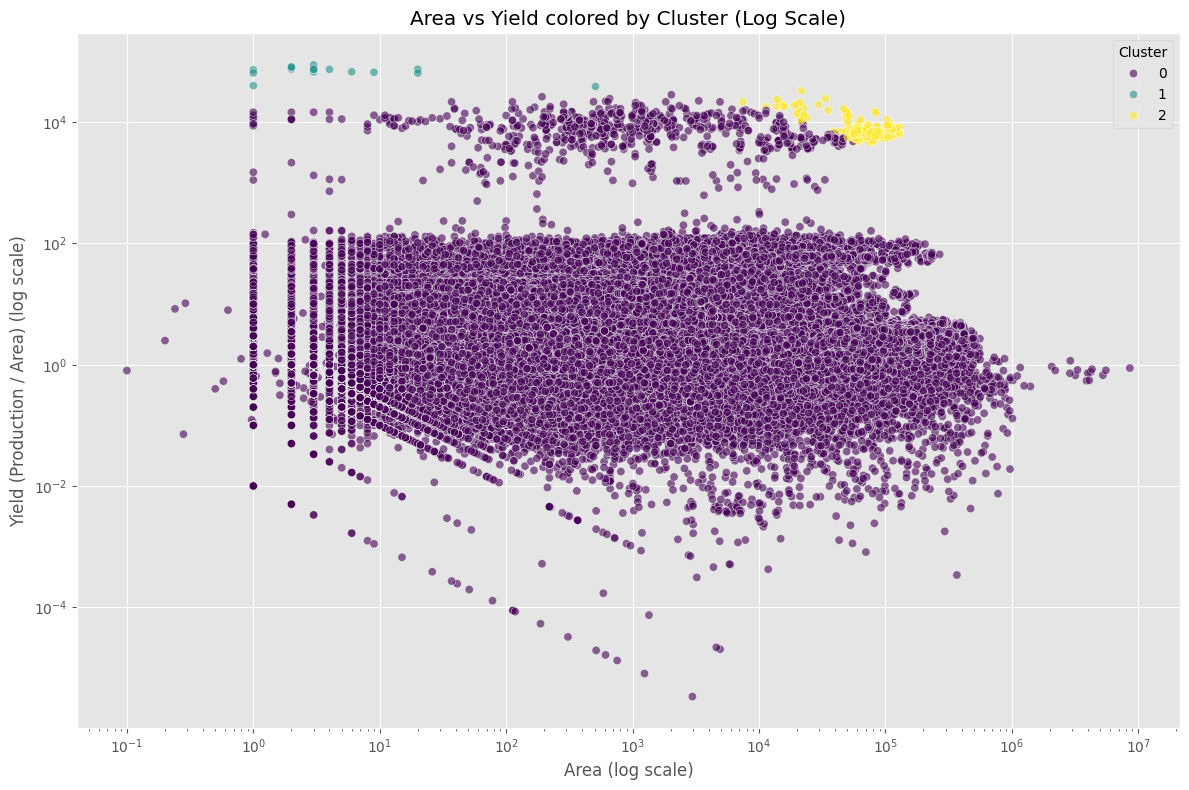

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=crop_production_df, x='Area', y='Yield', hue='Cluster', palette='viridis', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.title('Area vs Yield colored by Cluster (Log Scale)')
plt.xlabel('Area (log scale)')
plt.ylabel('Yield (Production / Area) (log scale)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

/tmp/ipykernel_907/3987581221.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='risk_level', data=crop_production_df, palette='coolwarm')


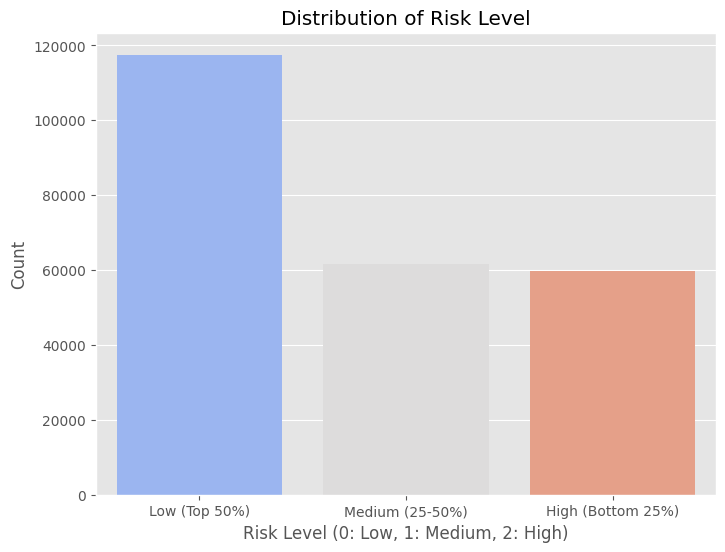

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='risk_level', data=crop_production_df, palette='coolwarm')
plt.title('Distribution of Risk Level')
plt.xlabel('Risk Level (0: Low, 1: Medium, 2: High)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Low (Top 50%)', 'Medium (25-50%)', 'High (Bottom 25%)'])
plt.show()

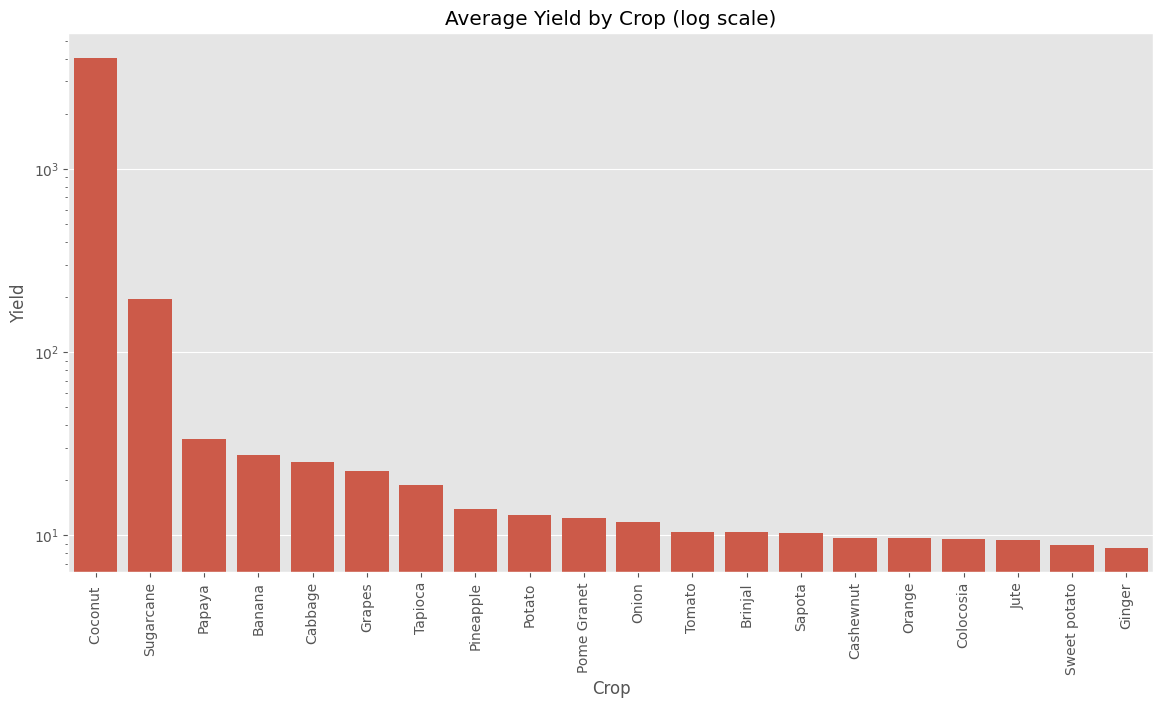

In [ ]:
plt.figure(figsize=(14,7))
sns.barplot(x='Crop', y='Yield', data=avg_yield_by_crop)
plt.yscale('log')
plt.xticks(rotation=90)
plt.title("Average Yield by Crop (log scale)")
plt.show()

In [ ]:
cluster_summary = crop_production_df.groupby('Cluster')[['Area', 'Production', 'Yield']].mean()
display(cluster_summary)

,Area,Production,Yield
Cluster,,,
0,12295.765476,1.423937e+05,30.455353
1,36.812500,1.587638e+06,69149.305556
2,70408.979538,5.495987e+08,8821.791330


In [ ]:
X_baseline = crop_production_df[['State', 'Crop', 'Season', 'Area']]
y_baseline = crop_production_df['risk_level']

categorical_features_baseline = ['State', 'Crop', 'Season']
numerical_features_baseline = ['Area']

preprocessor_baseline = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_baseline),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_baseline)
    ])

X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(
    X_baseline, y_baseline, test_size=0.2, random_state=42, stratify=y_baseline
)

rf_baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_baseline),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_baseline_pipeline.fit(X_train_baseline, y_train_baseline)
y_pred_baseline = rf_baseline_pipeline.predict(X_test_baseline)

accuracy_baseline = accuracy_score(y_test_baseline, y_pred_baseline)
precision_baseline = precision_score(y_test_baseline, y_pred_baseline, average='weighted')
recall_baseline = recall_score(y_test_baseline, y_pred_baseline, average='weighted')
f1_baseline = f1_score(y_test_baseline, y_pred_baseline, average='weighted')

In [ ]:
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_baseline),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

logistic_pipeline.fit(X_train_baseline, y_train_baseline)
y_pred_logistic = logistic_pipeline.predict(X_test_baseline)

accuracy_logistic = accuracy_score(y_test_baseline, y_pred_logistic)
precision_logistic = precision_score(y_test_baseline, y_pred_logistic, average='weighted')
recall_logistic = recall_score(y_test_baseline, y_pred_logistic, average='weighted')
f1_logistic = f1_score(y_test_baseline, y_pred_logistic, average='weighted')

In [ ]:
X_hybrid = crop_production_df[['State', 'Crop', 'Season', 'Area', 'Cluster']]
y_hybrid = crop_production_df['risk_level']

categorical_features_hybrid = ['State', 'Crop', 'Season']
numerical_features_hybrid = ['Area', 'Cluster']

preprocessor_hybrid = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_hybrid),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_hybrid)
    ])

X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(
    X_hybrid, y_hybrid, test_size=0.2, random_state=42, stratify=y_hybrid
)

rf_hybrid_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_hybrid),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_hybrid_pipeline.fit(X_train_hybrid, y_train_hybrid)
y_pred_hybrid = rf_hybrid_pipeline.predict(X_test_hybrid)

accuracy_hybrid = accuracy_score(y_test_hybrid, y_pred_hybrid)
precision_hybrid = precision_score(y_test_hybrid, y_pred_hybrid, average='weighted')
recall_hybrid = recall_score(y_test_hybrid, y_pred_hybrid, average='weighted')
f1_hybrid = f1_score(y_test_hybrid, y_pred_hybrid, average='weighted')

/tmp/ipykernel_907/1721217584.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


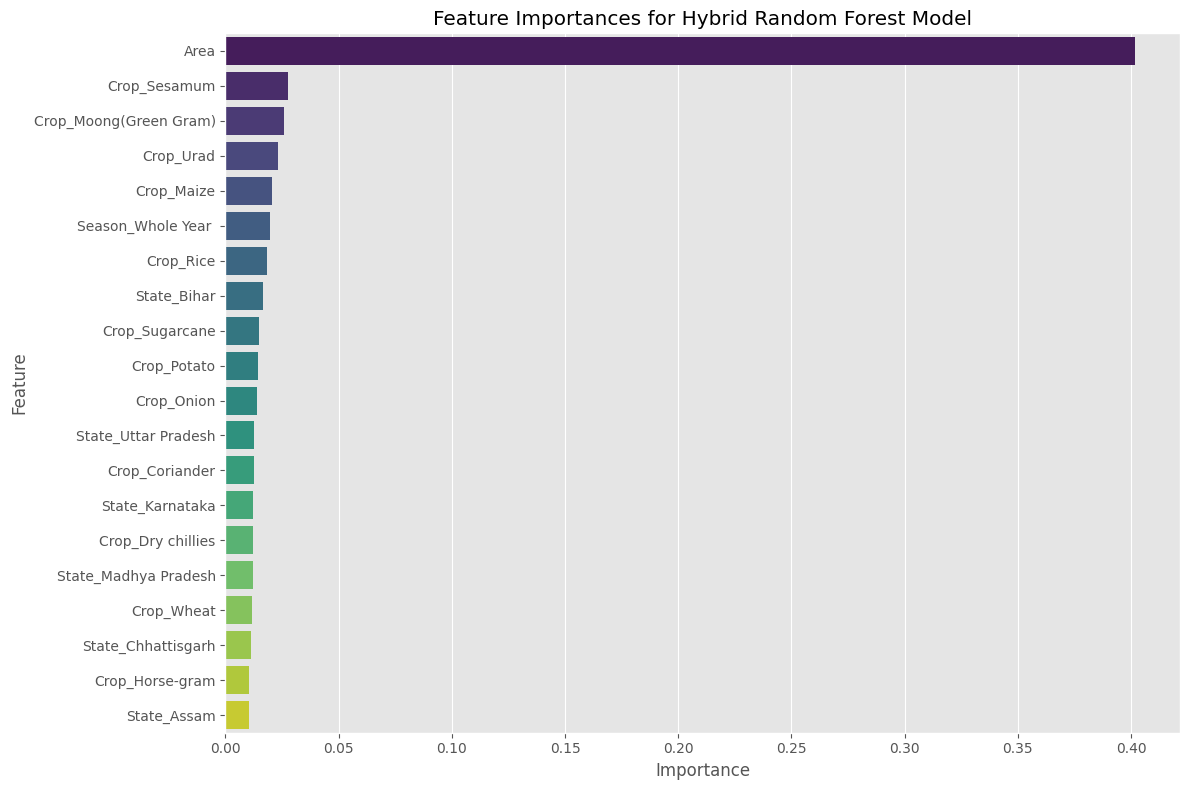

In [ ]:
feature_importances = rf_hybrid_pipeline.named_steps['classifier'].feature_importances_

onehot_features = rf_hybrid_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_hybrid)
all_features = numerical_features_hybrid + list(onehot_features)

importance_df = pd.DataFrame({'Feature': all_features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importances for Hybrid Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest Baseline', 'Hybrid Random Forest'],
    'Accuracy': [accuracy_logistic, accuracy_baseline, accuracy_hybrid],
    'Precision': [precision_logistic, precision_baseline, precision_hybrid],
    'Recall': [recall_logistic, recall_baseline, recall_hybrid],
    'F1 Score': [f1_logistic, f1_baseline, f1_hybrid]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.set_index('Model'))

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.735074,0.725365,0.735074,0.728601
Random Forest Baseline,0.769992,0.769752,0.769992,0.769871
Hybrid Random Forest,0.769951,0.769747,0.769951,0.769848
